# PPE Classification — 더미 데이터 테스트

> 실제 이미지 없이 전체 파이프라인이 정상 동작하는지 확인하는 테스트용 노트북

### 테스트 순서
```
1. 가상 이미지 + 파일명 자동 생성
2. 파일명 파싱 → 라벨 확인
3. MobileNetV2 모델 생성
4. 학습 (3 Epoch, 빠르게)
5. 임의 이미지로 추론 테스트
```

---
## 1. 모듈 로딩

>필요한 라이브러리 불러오기

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("NumPy Version      :", np.__version__)
print("TensorFlow Version :", tf.__version__)
print("Matplotlib Version :", plt.matplotlib.__version__)

NumPy Version      : 2.0.2
TensorFlow Version : 2.20.0
Matplotlib Version : 3.10.0


---
## 2. 가상 이미지 생성

> 실제 이미지 대신 색상으로 클래스를 구분한 더미 이미지를 만든다
>
> | 클래스 | 헬멧 | 조끼 | 대표 색상 |
> |--------|------|------|----------|
> | 00     | X    | X    | 빨강      |
> | 10     | O    | X    | 파랑      |
> | 01     | X    | O    | 초록      |
> | 11     | O    | O    | 노랑      |

>색상으로 구분된 가상 이미지 200장 자동 생성

더미 이미지 생성 완료: 200장
저장 위치: ./dummy_dataset


/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2327544308.py:53: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layou

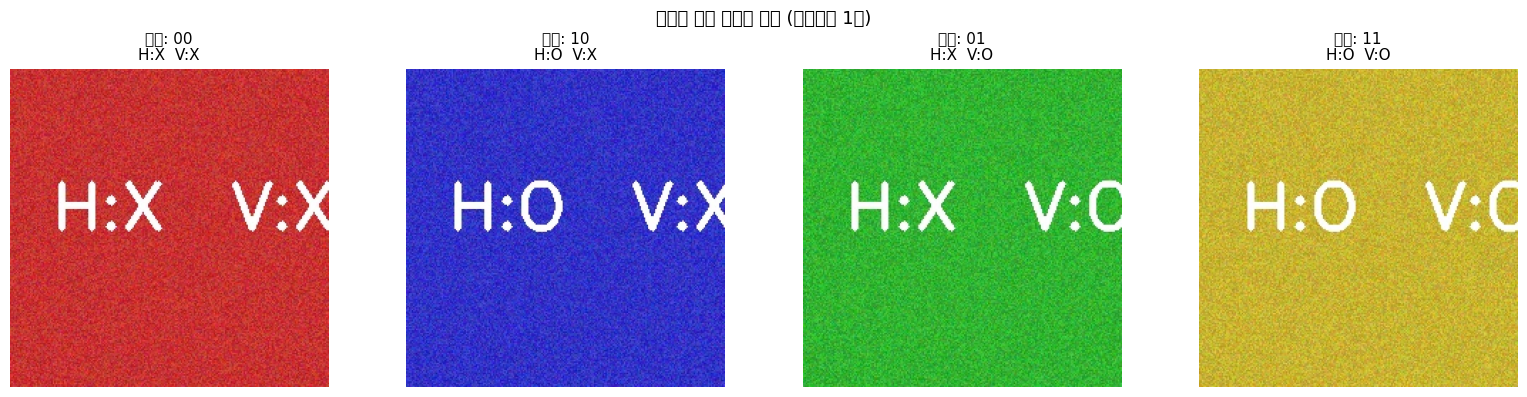

In [16]:
IMG_SIZE   = 224
N_PER_CLASS = 50   # 클래스당 이미지 수 (총 200장)
DUMMY_DIR  = './dummy_dataset'
os.makedirs(DUMMY_DIR, exist_ok=True)

# 클래스별 설정: (라벨, 배경색 RGB, 텍스트)
CLASS_CONFIG = [
    ('00', (200,  50,  50), 'H:X  V:X'),   # 빨강
    ('10', ( 50,  50, 200), 'H:O  V:X'),   # 파랑
    ('01', ( 50, 180,  50), 'H:X  V:O'),   # 초록
    ('11', (200, 180,  50), 'H:O  V:O'),   # 노랑
]

file_list = []
for label_str, color, text in CLASS_CONFIG:
    for i in range(N_PER_CLASS):
        # 배경색 + 랜덤 노이즈로 이미지 생성
        img = np.full((IMG_SIZE, IMG_SIZE, 3), color, dtype=np.uint8)
        noise = np.random.randint(-30, 30, img.shape, dtype=np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        # 텍스트 삽입 (시각적 구분용)
        cv2.putText(
            img, text,
            (30, IMG_SIZE // 2),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5,
            (255, 255, 255), 3
        )

        # 파일명: XXXX-HV.jpg
        idx      = len(file_list)
        filename = f"{idx:04d}-{label_str}.jpg"
        fpath    = os.path.join(DUMMY_DIR, filename)

        # RGB → BGR 변환 후 저장
        cv2.imwrite(fpath, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        file_list.append(fpath)

print(f"더미 이미지 생성 완료: {len(file_list)}장")
print(f"저장 위치: {DUMMY_DIR}")

# 샘플 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("생성된 더미 이미지 샘플 (클래스별 1장)", fontsize=13)
for ax, (label_str, color, text) in zip(axes, CLASS_CONFIG):
    sample_path = os.path.join(DUMMY_DIR, f"0000" if label_str == '00' else "").replace("", "")
    # 클래스 첫 번째 이미지
    class_files = [f for f in file_list if f"-{label_str}.jpg" in f]
    img = cv2.cvtColor(cv2.imread(class_files[0]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"라벨: {label_str}\n{text}", fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 3. 파일명 파싱 → 라벨 자동 생성

>파일명에서 helmet/vest 라벨 자동 추출 및 확인

In [17]:
def parse_label_from_filename(filepath):
    """
    XXXX-HV.jpg → [helmet, vest]
    H: 1=헬멧 착용, 0=미착용
    V: 1=조끼 착용, 0=미착용
    """
    name = os.path.splitext(os.path.basename(filepath))[0]
    if '-' not in name:
        return None
    label_str = name.split('-')[-1]
    if len(label_str) < 2:
        return None
    try:
        helmet, vest = int(label_str[0]), int(label_str[1])
    except ValueError:
        return None
    if helmet not in (0,1) or vest not in (0,1):
        return None
    return [helmet, vest]


# 파싱 확인
print("파일명 파싱 테스트")
print("-" * 45)
for f in file_list[:8]:   # 앞에서 8개만 출력
    lbl = parse_label_from_filename(f)
    print(f"  {os.path.basename(f):15s} → helmet={lbl[0]}, vest={lbl[1]}")

파일명 파싱 테스트
---------------------------------------------
  0000-00.jpg     → helmet=0, vest=0
  0001-00.jpg     → helmet=0, vest=0
  0002-00.jpg     → helmet=0, vest=0
  0003-00.jpg     → helmet=0, vest=0
  0004-00.jpg     → helmet=0, vest=0
  0005-00.jpg     → helmet=0, vest=0
  0006-00.jpg     → helmet=0, vest=0
  0007-00.jpg     → helmet=0, vest=0


---
## 4. 전체 이미지 로딩

>생성된 이미지 파일 읽어서 배열로 변환

In [18]:
images, labels = [], []

for fpath in sorted(file_list):
    lbl = parse_label_from_filename(fpath)
    if lbl is None:
        continue
    img = cv2.imread(fpath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)
    labels.append(lbl)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=np.float32)

print(f"images : {images.shape}")
print(f"labels : {labels.shape}")

images : (200, 224, 224, 3)
labels : (200, 2)


---
## 5. 클래스 분포 확인

>클래스별 데이터 수 확인 (분포 텍스트 출력)

In [19]:
combos = {'00':0, '10':0, '01':0, '11':0}
for lbl in labels:
    combos[f"{int(lbl[0])}{int(lbl[1])}"] += 1

print("=== 클래스 분포 ===")
for k, v in combos.items():
    bar = '█' * (v // 2)
    print(f"  {k}  {bar}  {v}장")

=== 클래스 분포 ===
  00  █████████████████████████  50장
  10  █████████████████████████  50장
  01  █████████████████████████  50장
  11  █████████████████████████  50장


---
## 6. Train / Test 분리

>학습용 80% / 검증용 20% 분리

In [20]:
train_data, test_data, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=123
)
print(f"train : {train_data.shape}")
print(f"test  : {test_data.shape}")

train : (160, 224, 224, 3)
test  : (40, 224, 224, 3)


---
## 7. 모델 생성 (MobileNetV2)

>MobileNetV2 전이학습 모델 생성 및 컴파일

In [21]:
inputs     = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x          = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet', include_top=False, input_tensor=x
)
base_model.trainable = False

x       = base_model.output
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(128, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation='sigmoid', name='ppe_output')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['binary_accuracy']
)
print("모델 생성 완료")
print(f"파라미터 수: {model.count_params():,}")

/tmp/ipykernel_407/1064429148.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


모델 생성 완료
파라미터 수: 2,422,210


---
## 8. 빠른 학습 (3 Epoch)
> 더미 데이터라 3번만 돌려도 동작 확인 가능
>빠른 학습으로 동작 확인

In [25]:
%%time
history = model.fit(
    train_data, train_labels,
    epochs          = 15,
    batch_size      = 32,
    validation_data = (test_data, test_labels),
    verbose         = 1
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.9375 - loss: 0.3875 - val_binary_accuracy: 1.0000 - val_loss: 0.3565
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - binary_accuracy: 0.9688 - loss: 0.3211 - val_binary_accuracy: 1.0000 - val_loss: 0.3013
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.9844 - loss: 0.2755 - val_binary_accuracy: 1.0000 - val_loss: 0.2560
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - binary_accuracy: 0.9844 - loss: 0.2490 - val_binary_accuracy: 1.0000 - val_loss: 0.2189
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - binary_accuracy: 0.9906 - loss: 0.2132 - val_binary_accuracy: 1.0000 - val_loss: 0.1873
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - binary_accuracy: 1.0000 - loss: 0.1746 - val_binary_accuracy: 1.0000 - val_loss: 0.1624
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - binary_accuracy: 0.9937 - loss: 0.1605 - val_binary_accuracy: 1.0000 - val_loss: 0.1414
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s

---
## 9. 결과 시각화

In [28]:
y_pred = model.predict(test_data)
THRESHOLD = 0.3
#       0.0     - 0.5  -     1.0
# 확실히 미착용 - 중간 - 확실히 착용

# THRESHOLD = 0.3 조금만 착용 같아도 착용으로 판정 / 높이면 애매한 판정 다 미착용으로 간주

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("추론 결과 (빨간 제목 = 오답)", fontsize=14)

for idx in range(10):
    ax = axes[idx // 5, idx % 5]
    ax.imshow(test_data[idx])

    h_true, v_true = int(test_labels[idx][0]), int(test_labels[idx][1])
    h_prob, v_prob = y_pred[idx][0],           y_pred[idx][1]
    h_pred, v_pred = int(h_prob >= THRESHOLD),  int(v_prob >= THRESHOLD)

    color = 'red' if (h_true != h_pred or v_true != v_pred) else 'black'
    ax.set_title(
        f"정답: H={h_true} V={v_true}\n"
        f"예측: H={h_pred}({h_prob:.2f}) V={v_pred}({v_prob:.2f})",
        fontsize=8, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## 10. ★ 임의 이미지 추론 테스트
> 아무 이미지나 넣어서 결과 확인

>단일 이미지 추론 함수 정의 및 3가지 테스트

In [29]:
def predict_single_image(model, img_input, threshold=0.3):
    """
    img_input : 파일 경로(str) 또는 numpy array (H, W, 3) RGB

    Returns: dict {helmet, vest, helmet_prob, vest_prob, label_str}
    """
    # 입력이 경로면 파일 읽기
    if isinstance(img_input, str):
        img = cv2.imread(img_input, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"이미지를 찾을 수 없어요: {img_input}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = img_input.copy()

    # 전처리
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_batch   = img_resized[np.newaxis, ...].astype(np.float32)  # (1,224,224,3)

    # 추론
    pred      = model.predict(img_batch, verbose=0)[0]
    h_prob, v_prob = float(pred[0]), float(pred[1])
    helmet    = int(h_prob >= threshold)
    vest      = int(v_prob >= threshold)
    label_str = f"{helmet}{vest}"

    return {
        'helmet'      : bool(helmet),
        'vest'        : bool(vest),
        'helmet_prob' : h_prob,
        'vest_prob'   : v_prob,
        'label_str'   : label_str,   # '00' / '10' / '01' / '11'
    }


def show_prediction(model, img_input, true_label=None, threshold=0.3):
    """
    이미지와 추론 결과를 함께 시각화
    true_label : '11' 형식 문자열 (정답을 알 때만 입력)
    """
    result = predict_single_image(model, img_input, threshold)

    if isinstance(img_input, str):
        img = cv2.cvtColor(cv2.imread(img_input), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    else:
        img = img_input

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')

    h_icon = '✅ 착용' if result['helmet'] else '❌ 미착용'
    v_icon = '✅ 착용' if result['vest']   else '❌ 미착용'

    title = (
        f"결과: [{result['label_str']}]\n"
        f"헬멧  {h_icon}  ({result['helmet_prob']:.2f})\n"
        f"조끼  {v_icon}  ({result['vest_prob']:.2f})"
    )
    if true_label:
        correct = '✅ 정답' if result['label_str'] == true_label else '❌ 오답'
        title += f"\n정답: [{true_label}]  {correct}"

    color = 'green' if (true_label is None or result['label_str'] == true_label) else 'red'
    plt.title(title, fontsize=11, color=color)
    plt.tight_layout()
    plt.show()

    return result


print("추론 함수 준비 완료!")

추론 함수 준비 완료!


### 테스트 A — 더미 이미지 4종류 각 1장씩 추론

>헬멧/조끼 각각 혼동행렬로 정확도 확인

더미 이미지 4종류 추론 테스트

파일: 0000-00.jpg


/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 54764 (\N{HANGUL SYLLABLE HEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 47719 (\N{HANGUL SYLLABLE MES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

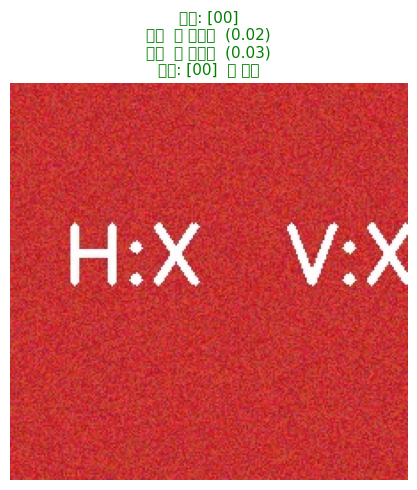

  → {'helmet': False, 'vest': False, 'helmet_prob': 0.0184064619243145, 'vest_prob': 0.02808157354593277, 'label_str': '00'}

파일: 0050-10.jpg


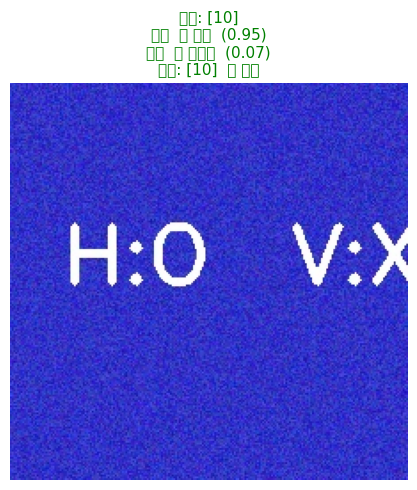

  → {'helmet': True, 'vest': False, 'helmet_prob': 0.9519991278648376, 'vest_prob': 0.06944537162780762, 'label_str': '10'}

파일: 0100-01.jpg


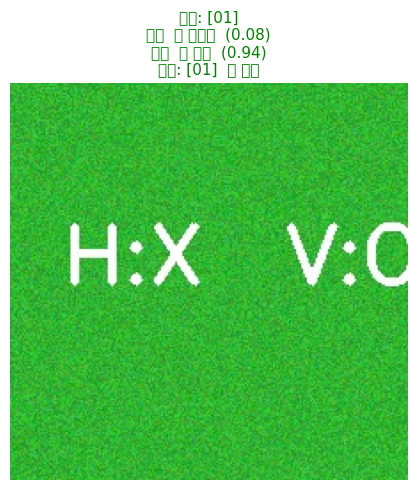

  → {'helmet': False, 'vest': True, 'helmet_prob': 0.07570316642522812, 'vest_prob': 0.9386175274848938, 'label_str': '01'}

파일: 0150-11.jpg


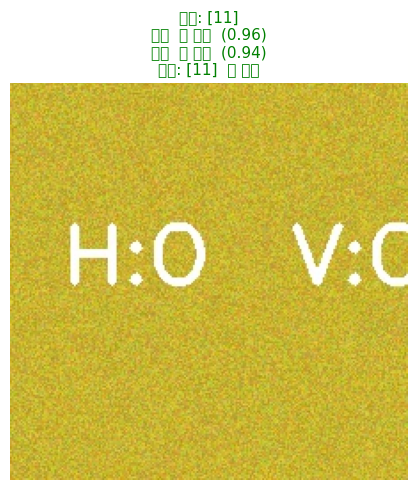

  → {'helmet': True, 'vest': True, 'helmet_prob': 0.9642359018325806, 'vest_prob': 0.9382787942886353, 'label_str': '11'}


In [30]:
print("=" * 50)
print("더미 이미지 4종류 추론 테스트")
print("=" * 50)

for label_str, _, _ in CLASS_CONFIG:
    # 해당 클래스 파일 중 첫 번째
    target = [f for f in file_list if f"-{label_str}.jpg" in f][0]
    print(f"\n파일: {os.path.basename(target)}")
    result = show_prediction(model, target, true_label=label_str)
    print(f"  → {result}")

### 테스트 B — 직접 경로 입력해서 추론
> 내 컴퓨터에 있는 아무 사진이나 경로를 넣어보세요

In [31]:
# ★ 여기에 테스트하고 싶은 이미지 경로를 입력하세요
MY_IMAGE_PATH = r'C:/Users/본인이름/Desktop/test.jpg'

# ─────────────────────────────────────────────
if os.path.exists(MY_IMAGE_PATH):
    result = show_prediction(model, MY_IMAGE_PATH)
    print("추론 결과:", result)
else:
    print(f"⚠️  파일을 찾을 수 없어요: {MY_IMAGE_PATH}")
    print("   MY_IMAGE_PATH 를 올바른 경로로 수정해주세요.")

⚠️  파일을 찾을 수 없어요: C:/Users/본인이름/Desktop/test.jpg
   MY_IMAGE_PATH 를 올바른 경로로 수정해주세요.


### 테스트 C — 랜덤 색상 이미지로 추론 (경로 없어도 됨)

랜덤 이미지 추론 결과:


/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 54764 (\N{HANGUL SYLLABLE HEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 47719 (\N{HANGUL SYLLABLE MES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2156402794.py:67: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

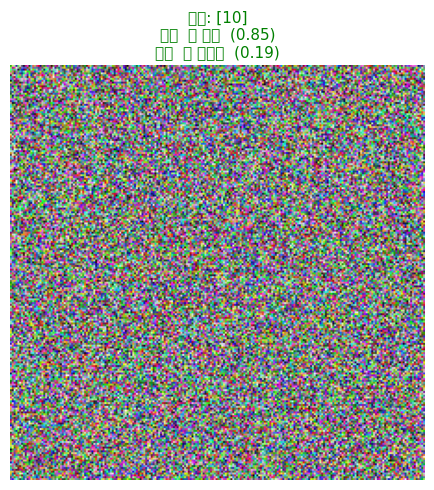

{'helmet': True, 'vest': False, 'helmet_prob': 0.8542907238006592, 'vest_prob': 0.18735696375370026, 'label_str': '10'}


In [32]:
# 완전 랜덤 이미지 생성 후 추론
random_img = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

print("랜덤 이미지 추론 결과:")
result = show_prediction(model, random_img)
print(result)

---
## 11. 혼동행렬

>헬멧/조끼 각각 혼동행렬로 정확도 확인

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step


/tmp/ipykernel_407/2681435771.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2681435771.py:22: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_407/2681435771.py:22: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

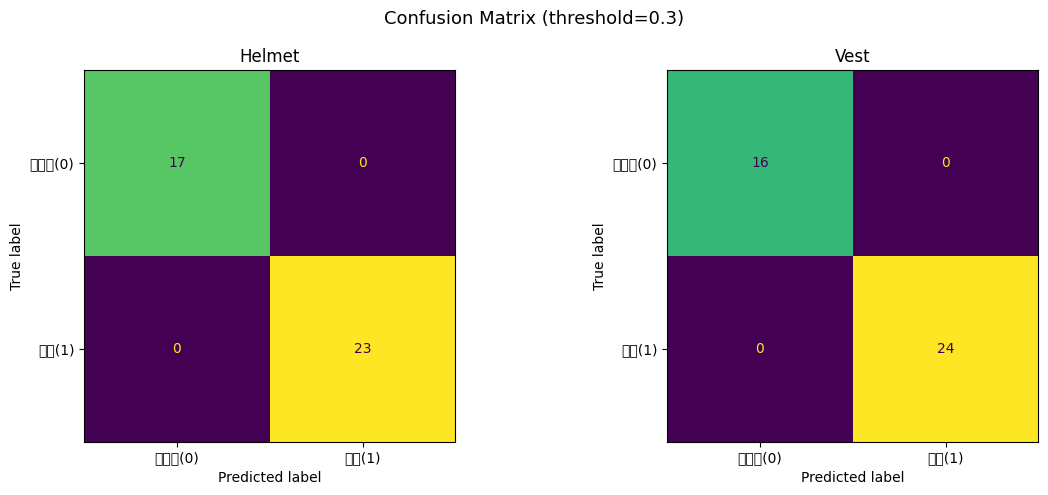

헬멧 정확도 : 100.0%  ✅
조끼 정확도 : 100.0%  ✅

※ 더미 데이터라 정확도가 낮아도 정상이에요. 실제 이미지로 학습하면 올라갑니다.


In [33]:
THRESHOLD   = 0.3
y_pred_all  = model.predict(test_data)

helmet_true = test_labels[:, 0].astype(int)
helmet_pred = (y_pred_all[:, 0] >= THRESHOLD).astype(int)
vest_true   = test_labels[:, 1].astype(int)
vest_pred   = (y_pred_all[:, 1] >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in zip(
    axes,
    [helmet_true, vest_true],
    [helmet_pred, vest_pred],
    ['Helmet', 'Vest']
):
    cm   = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['미착용(0)', '착용(1)'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f'Confusion Matrix (threshold={THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

h_acc = (helmet_true == helmet_pred).mean()
v_acc = (vest_true   == vest_pred).mean()
print(f"헬멧 정확도 : {h_acc*100:.1f}%  {'✅' if h_acc>=0.8 else '❌  (더미 데이터라 낮을 수 있음)'}")
print(f"조끼 정확도 : {v_acc*100:.1f}%  {'✅' if v_acc>=0.8 else '❌  (더미 데이터라 낮을 수 있음)'}")
print("\n※ 더미 데이터라 정확도가 낮아도 정상이에요. 실제 이미지로 학습하면 올라갑니다.")

---
## 12. 더미 파일 정리

In [34]:
# 테스트 완료 후 더미 폴더 삭제 (원하면 실행)
# shutil.rmtree(DUMMY_DIR)
# print(f"더미 폴더 삭제: {DUMMY_DIR}")
print("(삭제하려면 위 두 줄 주석 해제 후 실행)")

(삭제하려면 위 두 줄 주석 해제 후 실행)
